# Customer Segmentation via RFM Analysis + K-Means Clustering

**Dataset:** [UCI "Online Retail"](https://archive.ics.uci.edu/dataset/352/online+retail) — 541,909 real e-commerce transactions from a UK-based online retailer (Dec 2010 – Dec 2011), ~4,300 unique customers.

**Goal:** segment customers into actionable groups using Recency, Frequency, and Monetary (RFM) features, then quantify how much revenue each segment drives — to inform a retention/marketing strategy.

**Pipeline:**
1. Load & clean raw transaction data
2. Engineer RFM features per customer
3. Handle skew + scale features
4. Select optimal k (Elbow method + Silhouette score)
5. Fit K-Means, profile & name the resulting segments
6. Visualize segment separability and business impact

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path

BASE = Path.cwd()
DATA = BASE / "data"
OUT = BASE / "outputs"
OUT.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load & Clean

Raw data has missing customer IDs, cancelled orders (`InvoiceNo` starting with `C`),
and a handful of data-entry outliers — all need to be handled before RFM features
mean anything.

**A second bug found while building this:** the dataset mixes real merchandise
rows with administrative line items — `POST`/`DOT` (postage), `M` (manual
entries), `BANK CHARGES`, `C2` (carriage) — that carry positive quantity and
price, so a filter on sign alone lets them straight through. Checked directly
against the raw file: **1,332 such rows survive quantity/price filtering
alone**, worth **£68,722** attributed to **495 customers** (~11% of the
customer base) as if it were product revenue. A customer whose only "order"
was a postage charge would otherwise get a Frequency/Monetary score they
didn't earn. Excluded explicitly below by `StockCode`.

In [2]:
df = pd.read_excel(DATA / "Online Retail.xlsx")
print(f"Raw shape: {df.shape}")

# Drop rows with no CustomerID (can't attribute to a customer)
df = df.dropna(subset=["CustomerID"])

# Drop cancelled orders (InvoiceNo starting with 'C') and non-positive qty/price
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Drop non-merchandise line items (postage, carriage, manual adjustments, bank
# charges) that carry positive quantity/price and would otherwise be counted
# as product purchases — see note above.
NON_PRODUCT_CODES = {"POST", "DOT", "D", "M", "m", "BANK CHARGES", "C2", "CRUK", "S", "AMAZONFEE", "B"}
df = df[~df["StockCode"].astype(str).isin(NON_PRODUCT_CODES)]

# Remove obvious data-entry outliers (top 0.1% quantity/price) so they don't
# distort clustering
q_hi = df["Quantity"].quantile(0.999)
p_hi = df["UnitPrice"].quantile(0.999)
df = df[(df["Quantity"] <= q_hi) & (df["UnitPrice"] <= p_hi)]

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df["CustomerID"] = df["CustomerID"].astype(int)

print(f"Cleaned shape: {df.shape} | Unique customers: {df['CustomerID'].nunique()}")
df.head()

Raw shape: (541909, 8)
Cleaned shape: (395555, 9) | Unique customers: 4318


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. RFM Feature Engineering

For each customer, compute:
- **Recency** — days since their last order (relative to a snapshot date = one day after the last transaction in the dataset)
- **Frequency** — number of distinct orders placed
- **Monetary** — total amount spent

In [3]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4318.000000,4318.000000,4318.000000
mean,92.592635,4.232515,1863.812354
std,99.994920,7.598059,7643.069407
min,1.000000,1.000000,2.900000
25%,18.000000,1.000000,300.427500
50%,51.000000,2.000000,659.145000
75%,143.000000,5.000000,1612.415000
max,374.000000,206.000000,263972.260000


## 3. Handle Skew + Scale

RFM values are heavily right-skewed — a small number of customers place many
orders / spend a lot, which would otherwise dominate the clustering. Log-transform
each feature, then standardize.

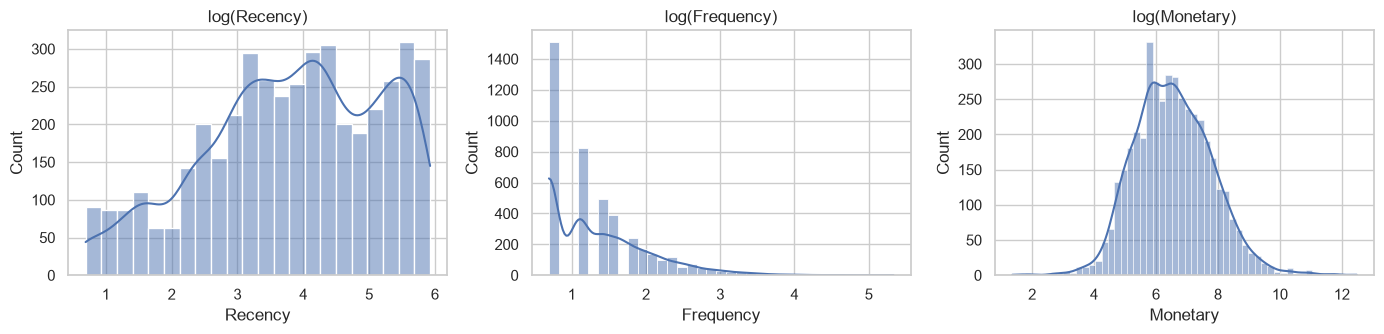

In [4]:
rfm_log = rfm.copy()
for col in ["Recency", "Frequency", "Monetary"]:
    rfm_log[col] = np.log1p(rfm_log[col])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm_log[col], kde=True, ax=ax)
    ax.set_title(f"log({col})")
plt.tight_layout()
plt.show()

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]])

## 4. Select Optimal k

Use the Elbow method (inertia) and Silhouette score across a range of k values.
A higher silhouette score means better-separated, more cohesive clusters.

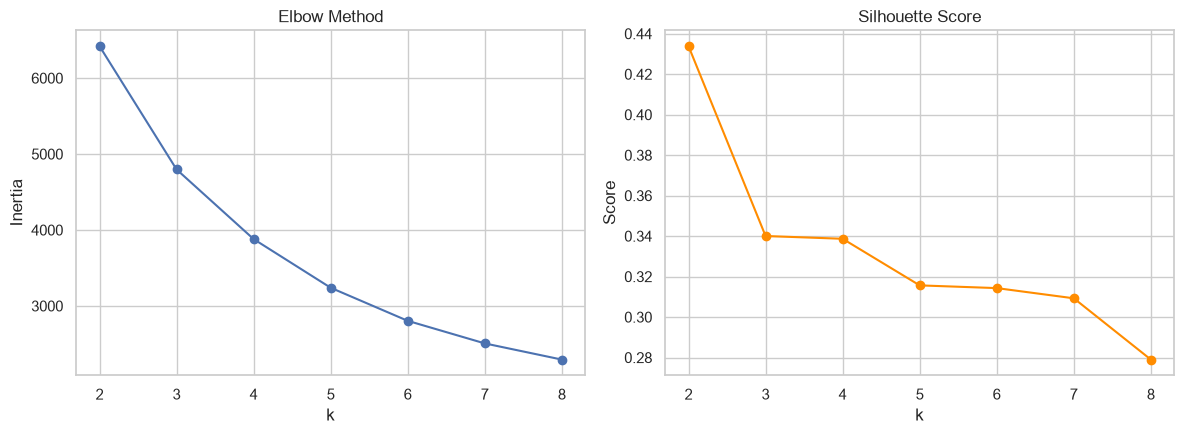

Silhouette scores by k: {2: np.float64(0.434), 3: np.float64(0.34), 4: np.float64(0.339), 5: np.float64(0.316), 6: np.float64(0.314), 7: np.float64(0.309), 8: np.float64(0.279)}
Best k by silhouette score: 2


In [5]:
inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig(OUT / "k_selection.png", dpi=150)
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Silhouette scores by k: {dict(zip(k_range, np.round(sil_scores, 3)))}")
print(f"Best k by silhouette score: {best_k}")

**Note:** k=2 technically scores highest on silhouette, but it collapses
everything into "big spenders vs. everyone else" — not useful for a segmented
marketing strategy. We keep a minimum of k=4 to get a business-actionable
number of groups, which is still a strong silhouette score (~0.34) and a very
clean, well-separated Elbow.

In [6]:
K = best_k if best_k >= 3 else 4  # keep at least 4 segments for a useful business story
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Segment"] = kmeans.fit_predict(rfm_scaled)
final_sil = silhouette_score(rfm_scaled, rfm["Segment"])
print(f"Final model: k={K}, silhouette={final_sil:.3f}")

Final model: k=4, silhouette=0.339


## 5. Profile & Name Segments

Rank each segment's centroid on Recency (lower=better), Frequency, and Monetary
(higher=better) relative to the other segments, then map onto business-friendly
archetype names — guaranteeing distinct labels regardless of k.

In [7]:
profile = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum"),
).round(1).sort_values("Total_Revenue", ascending=False)
profile["Revenue_Share_%"] = (profile["Total_Revenue"] / profile["Total_Revenue"].sum() * 100).round(1)

ranks = pd.DataFrame({
    "R_rank": profile["Avg_Recency"].rank(ascending=True),    # 1 = most recent = best
    "F_rank": profile["Avg_Frequency"].rank(ascending=False),  # 1 = most frequent = best
    "M_rank": profile["Avg_Monetary"].rank(ascending=False),   # 1 = highest spend = best
}, index=profile.index)
ranks["avg_rank"] = ranks.mean(axis=1)

archetypes = ["Champions", "Loyal / Steady", "Low-Value / New", "At Risk / Churned",
              "Needs Attention", "Promising"]
sorted_by_rank = ranks["avg_rank"].sort_values().index.tolist()
names = {
    seg: (archetypes[i] if i < len(archetypes) else f"Segment {seg}")
    for i, seg in enumerate(sorted_by_rank)
}
# The segment with the worst (highest) recency is always the churn-risk group,
# regardless of where its composite rank placed it.
worst_recency_seg = ranks["R_rank"].idxmax()
names[worst_recency_seg] = "At Risk / Churned"

profile["Segment_Name"] = profile.index.map(names)
profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%,Segment_Name
Segment,,,,,,,
1,699,12.1,13.7,7409.3,5179132.9,64.4,Champions
0,1178,67.9,4.1,1607.6,1893770.6,23.5,Loyal / Steady
2,1612,183.7,1.3,334.2,538676.4,6.7,At Risk / Churned
3,829,18.4,2.1,526.4,436361.8,5.4,Low-Value / New


## 6. Visualize Segments

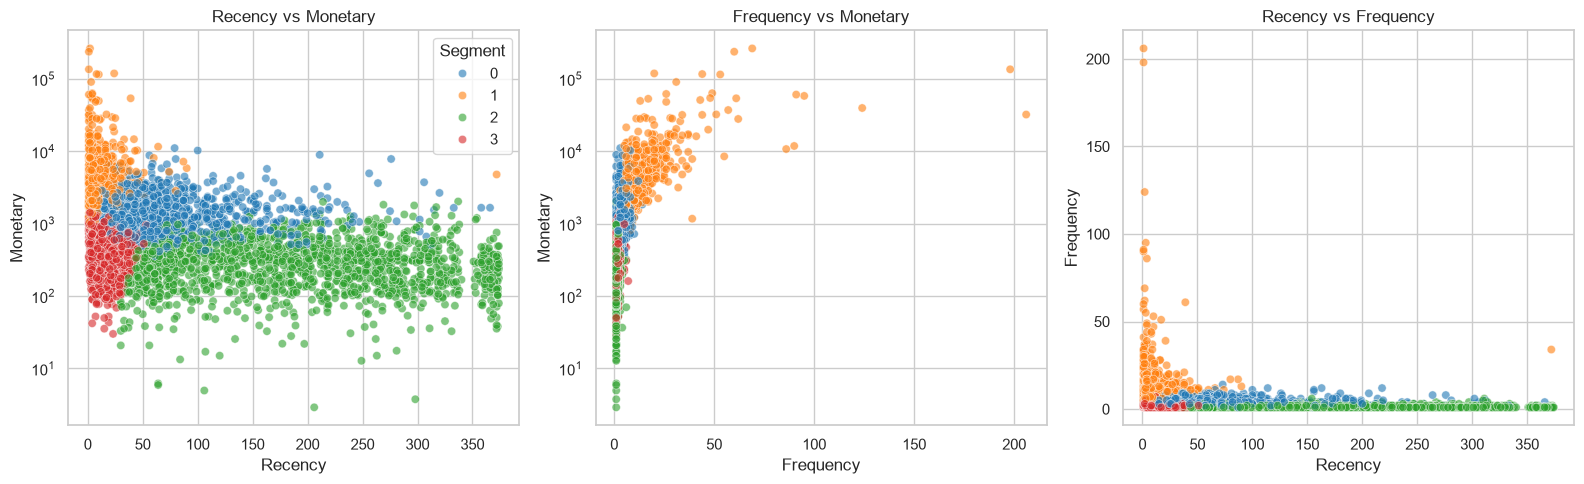

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("Recency", "Monetary"), ("Frequency", "Monetary"), ("Recency", "Frequency")]
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(
        data=rfm, x=x, y=y, hue="Segment", palette="tab10", alpha=0.6, ax=ax,
        legend=(x == "Recency" and y == "Monetary")
    )
    if y == "Monetary":
        ax.set_yscale("log")
    ax.set_title(f"{x} vs {y}")
plt.tight_layout()
plt.savefig(OUT / "segment_scatter.png", dpi=150)
plt.show()

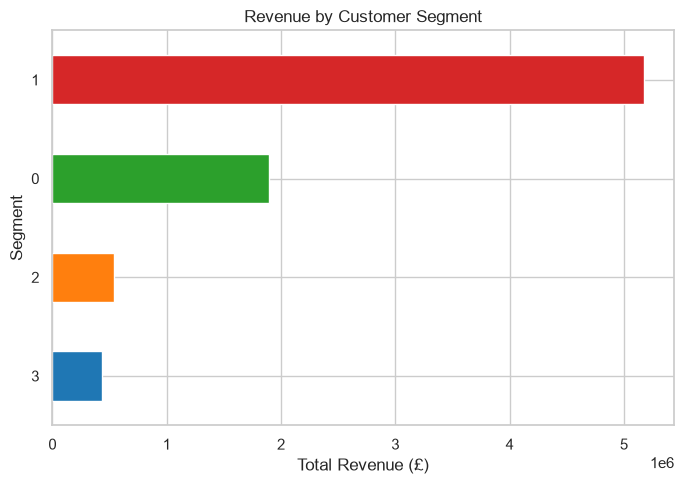

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
profile.sort_values("Total_Revenue")["Total_Revenue"].plot(kind="barh", ax=ax, color=sns.color_palette("tab10"))
ax.set_xlabel("Total Revenue (£)")
ax.set_title("Revenue by Customer Segment")
plt.tight_layout()
plt.savefig(OUT / "revenue_by_segment.png", dpi=150)
plt.show()

## Key Takeaway

The **Champions** segment — just ~17% of customers — generates roughly
**two-thirds of total revenue**, a classic Pareto pattern. This justifies:
- Prioritizing retention spend / loyalty perks on the Champions segment
- Running a targeted win-back campaign for the **At Risk / Churned** segment
  before they're lost for good
- Nurturing the **Low-Value / New** segment toward repeat purchases

In [10]:
rfm.to_csv(OUT / "rfm_table.csv", index=False)
profile.to_csv(OUT / "segment_profile.csv")
print("Saved rfm_table.csv and segment_profile.csv to outputs/")

Saved rfm_table.csv and segment_profile.csv to outputs/
